In [2]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm                                   # 내장 데이터셋 로더
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd      # 사후검정(Tukey HSD)

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 재현성: 같은 난수를 항상 같게 만듭니다. (시뮬레이션 셀에 적용)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("statsmodels :", sm.__version__)

준비 완료!
numpy       : 2.4.6
pandas      : 3.0.3
statsmodels : 0.14.6


In [3]:
# [C2] ── 실습 데이터 로드 — 모두 라이브러리가 제공하는 데이터셋 ──
#   · tips     (seaborn)                : 식당 영수증 → 2표본 t-test
#   · penguins (seaborn)                : 펭귄 종·체중 → 일원 ANOVA + Tukey
#   · jtrain   (statsmodels/Rdatasets)  : 같은 기업의 87/88 불량률 → 대응표본 t-test
#   · Star     (statsmodels/Rdatasets)  : Project STAR 무작위 실험 → 종합 실습 ANOVA

tips = sns.load_dataset("tips")

# 체중·종에 결측이 있는 행은 검정에서 쓸 수 없으므로 미리 제거합니다.
penguins = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])  # 결측(NaN) 제거

# ── 대응표본용: 같은 기업(fcode)의 1987 vs 1988 불량률을 나란히 놓기 ──
jtrain = sm.datasets.get_rdataset("jtrain", "wooldridge").data
scrap = (jtrain.pivot_table(index="fcode", columns="year", values="scrap")   # 행=기업, 열=연도
                [[1987, 1988]].dropna())                                     # 두 해 모두 기록된 기업만
before, after = scrap[1987], scrap[1988]      # '같은 기업'의 전 / 후  → 짝지어진 두 측정

# ── 종합 실습용: Project STAR (학급 유형 3종 무작위 배정) ──
star = sm.datasets.get_rdataset("Star", "Ecdat").data

print("로드 완료 ✓")
print(f"  tips     {tips.shape}  — 컬럼: {list(tips.columns)}")
print(f"  penguins {penguins.shape}  — 종: {penguins['species'].unique().tolist()}")
print(f"  scrap    {scrap.shape}   — 87·88년 모두 기록된 기업 {len(scrap)}곳의 불량률(%)")
print(f"           1987 평균 {before.mean():.2f}  →  1988 평균 {after.mean():.2f}")
print(f"  star     {star.shape} — 학급 유형: {star['classk'].unique().tolist()}")
tips.head(3)

로드 완료 ✓
  tips     (244, 7)  — 컬럼: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
  penguins (342, 7)  — 종: ['Adelie', 'Chinstrap', 'Gentoo']
  scrap    (54, 2)   — 87·88년 모두 기록된 기업 54곳의 불량률(%)
           1987 평균 4.61  →  1988 평균 3.79
  star     (5748, 8) — 학급 유형: ['small.class', 'regular.with.aide', 'regular']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


In [4]:
# [C3] 가설검정 6단계 — tips: 남성 vs 여성 결제 금액
male   = tips[tips["sex"] == "Male"]["total_bill"]
female = tips[tips["sex"] == "Female"]["total_bill"]
alpha  = 0.05

# [3] 두 독립 집단 평균 비교 → 2표본 t-test (분산 다를 수 있으니 Welch)
t, p = stats.ttest_ind(male, female, equal_var=False)             # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)

print(f"[1-2] H0: 남=여  vs  H1: 남≠여")
print(f"      남 평균 {male.mean():.2f} (n={len(male)})  /  여 평균 {female.mean():.2f} (n={len(female)})")
print(f"[4]   t = {t:.2f},  p = {p:.3f}")
print(f"[5]   p {'<' if p<alpha else '≥'} α(={alpha}) → H0 {'기각: 차이 있다' if p<alpha else '기각 못함'}")
print(f"[6]   해석: 남성 결제 금액이 통계적으로 유의하게 높습니다. (단, '얼마나' 큰지는 Part 7)")

[1-2] H0: 남=여  vs  H1: 남≠여
      남 평균 20.74 (n=157)  /  여 평균 18.06 (n=87)
[4]   t = 2.37,  p = 0.019
[5]   p < α(=0.05) → H0 기각: 차이 있다
[6]   해석: 남성 결제 금액이 통계적으로 유의하게 높습니다. (단, '얼마나' 큰지는 Part 7)


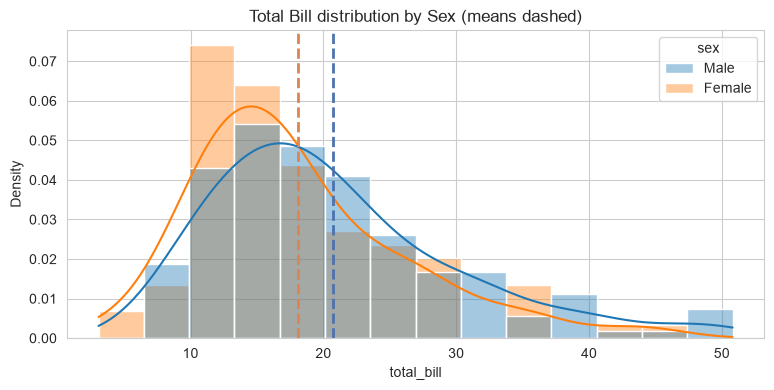

두 분포가 겹치는 정도가 클수록 '차이가 우연일' 여지가 큽니다. 평균차 2.69달러.


In [5]:
# [C4] [그림] t-test가 비교하는 '두 분포' — 남녀 결제 금액
fig, ax = plt.subplots(figsize=(9, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.histplot(data=tips, x="total_bill", hue="sex", kde=True, stat="density",  # 히스토그램 — 값이 어디에 몰려 있나
             common_norm=False, alpha=0.4, ax=ax)
ax.axvline(male.mean(),   color="#4C72B0", ls="--", lw=2)
ax.axvline(female.mean(), color="#DD8452", ls="--", lw=2)
ax.set_title("Total Bill distribution by Sex (means dashed)")
plt.show()
print(f"두 분포가 겹치는 정도가 클수록 '차이가 우연일' 여지가 큽니다. 평균차 {male.mean()-female.mean():.2f}달러.")

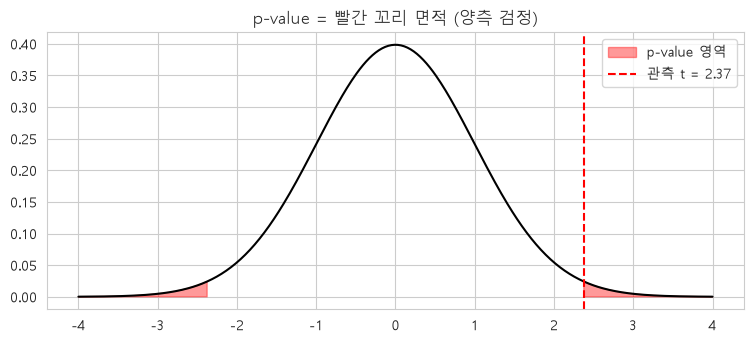

관측 t보다 더 극단적인 값이 H0(차이 없음)에서 나올 확률 = p-value


In [6]:
# [C5] [도식] p-value = t 분포에서 '관측값보다 극단적인' 꼬리 면적

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
dfree = len(male) + len(female) - 2
xx = np.linspace(-4, 4, 400)                                      # 구간을 균등 간격으로 쪼갠 x축 값
t_obs, _ = stats.ttest_ind(male, female, equal_var=False)         # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
fig, ax = plt.subplots(figsize=(9, 3.6))                          # 그래프 하나를 그릴 도화지 준비
ax.plot(xx, stats.t.pdf(xx, dfree), "k", lw=1.5)
ax.fill_between(xx, stats.t.pdf(xx, dfree), where=(np.abs(xx) >= abs(t_obs)),  # 곡선 아래 영역을 색으로 채움(= 면적은 확률)
                color="red", alpha=0.4, label="p-value 영역")
ax.axvline(t_obs, color="red", ls="--", label=f"관측 t = {t_obs:.2f}")  # 세로 기준선 표시
ax.set_title("p-value = 빨간 꼬리 면적 (양측 검정)"); ax.legend(); plt.show()
print("관측 t보다 더 극단적인 값이 H0(차이 없음)에서 나올 확률 = p-value")

In [7]:
# [C6] [확인] 같은 데이터 — 양측 vs 단측 p-value
g_dinner = tips[tips["time"] == "Dinner"]["total_bill"]
g_lunch  = tips[tips["time"] == "Lunch"]["total_bill"]

t_two = stats.ttest_ind(g_dinner, g_lunch)                          # 양측 (기본)
t_one = stats.ttest_ind(g_dinner, g_lunch, alternative="greater")  # 단측 (저녁 > 점심)
print(f"양측검정 : t = {t_two.statistic:6.3f},  p = {t_two.pvalue:.4f}")
print(f"단측검정 : t = {t_one.statistic:6.3f},  p = {t_one.pvalue:.4f}   (방향 가설: 저녁 > 점심)")
print()
print("→ 같은 t값인데 단측 p가 양측 p의 약 절반입니다(한쪽 꼬리만 보므로).")

양측검정 : t =  2.898,  p = 0.0041
단측검정 : t =  2.898,  p = 0.0021   (방향 가설: 저녁 > 점심)

→ 같은 t값인데 단측 p가 양측 p의 약 절반입니다(한쪽 꼬리만 보므로).


In [8]:
# ─────────────────────────────────────────────
# [C3] tips: time(Lunch/Dinner)에 따른 total_bill 차이 검정
# ─────────────────────────────────────────────

# time 컬럼 값 확인
print(tips['time'].value_counts())

lunch  = tips.loc[tips['time'] == 'Lunch',  'total_bill']
dinner = tips.loc[tips['time'] == 'Dinner', 'total_bill']

print(f"\nLunch  : n={len(lunch)}, 평균={lunch.mean():.3f}, 표준편차={lunch.std():.3f}")
print(f"Dinner : n={len(dinner)}, 평균={dinner.mean():.3f}, 표준편차={dinner.std():.3f}")

# 등분산 여부 확인 (Levene 검정) → equal_var 옵션 결정에 참고
levene_stat, levene_p = stats.levene(lunch, dinner)
print(f"\nLevene 등분산 검정: statistic={levene_stat:.3f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05   # p>0.05면 등분산 가정 OK

# 2표본 t-test (Welch 권장: 등분산 가정이 애매할 때도 안전)
t_obs, p_val = stats.ttest_ind(lunch, dinner, equal_var=equal_var)

print(f"\n[t-test 결과]")
print(f"등분산 가정: {equal_var}")
print(f"t 통계량 = {t_obs:.4f}")
print(f"p-value  = {p_val:.4f}")

time
Dinner    176
Lunch      68
Name: count, dtype: int64

Lunch  : n=68, 평균=17.169, 표준편차=7.714
Dinner : n=176, 평균=20.797, 표준편차=9.142

Levene 등분산 검정: statistic=2.691, p=0.1022

[t-test 결과]
등분산 가정: True
t 통계량 = -2.8976
p-value  = 0.0041


In [9]:
# ─────────────────────────────────────────────
# [C4] 가설검정 6단계 중 [5] 판단 / [6] 결론 작성
# ─────────────────────────────────────────────

alpha = 0.05

print("① H0 (귀무가설) : Lunch와 Dinner의 total_bill 평균은 차이가 없다.")
print("   H1 (대립가설) : Lunch와 Dinner의 total_bill 평균은 차이가 있다.")
print(f"② 유의수준 α = {alpha}")
print(f"③ 검정통계량 t = {t_obs:.4f}")
print(f"④ p-value = {p_val:.4f}")

# [5] 판단: p-value와 유의수준 비교
print(f"\n[5] 판단")
if p_val < alpha:
    decision = "기각한다 (Reject H0)"
    print(f"p-value({p_val:.4f}) < α({alpha}) → H0를 {decision}")
else:
    decision = "기각하지 못한다 (Fail to reject H0)"
    print(f"p-value({p_val:.4f}) ≥ α({alpha}) → H0를 {decision}")

# [6] 결론: 통계적 언어 → 실제 맥락 언어로 해석
print(f"\n[6] 결론")
mean_diff = lunch.mean() - dinner.mean()
if p_val < alpha:
    print(f"Lunch와 Dinner의 평균 결제 금액(total_bill)에는 통계적으로 유의미한 차이가 있다.")
    print(f"(Lunch 평균 - Dinner 평균 = {mean_diff:.2f}, 방향: "
          f"{'Lunch가 더 높음' if mean_diff > 0 else 'Dinner가 더 높음'})")
else:
    print(f"Lunch와 Dinner의 평균 결제 금액(total_bill) 차이는 통계적으로 유의미하다고 보기 어렵다.")
    print(f"(관측된 차이 {mean_diff:.2f}는 우연(샘플링 변동)만으로도 충분히 설명 가능한 수준)")

① H0 (귀무가설) : Lunch와 Dinner의 total_bill 평균은 차이가 없다.
   H1 (대립가설) : Lunch와 Dinner의 total_bill 평균은 차이가 있다.
② 유의수준 α = 0.05
③ 검정통계량 t = -2.8976
④ p-value = 0.0041

[5] 판단
p-value(0.0041) < α(0.05) → H0를 기각한다 (Reject H0)

[6] 결론
Lunch와 Dinner의 평균 결제 금액(total_bill)에는 통계적으로 유의미한 차이가 있다.
(Lunch 평균 - Dinner 평균 = -3.63, 방향: Dinner가 더 높음)


전체 데이터(n=68+176)로 검정했을 때 p-value = 0.0041
→ 결론: 유의미한 차이 있음

10건씩 무작위로 뽑아 검정하기를 1000번 반복한 결과
→ H0를 기각한 비율: 146/1000 (14.6%)
→ p-value 평균: 0.3747, 중앙값: 0.3066


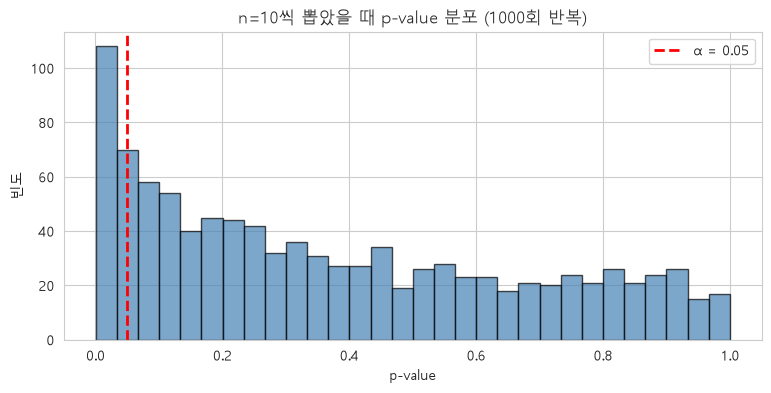

In [10]:
# ─────────────────────────────────────────────
# [C5] 표본 크기를 10건씩으로 줄이면 결론이 달라질까? (반복 시뮬레이션)
# ─────────────────────────────────────────────

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

np.random.seed(42)
n_sim = 1000      # 1000번 반복해서 "10건씩 뽑았을 때" 결론이 얼마나 달라지는지 확인
n_sample = 10

reject_count = 0
p_values_small = []

for i in range(n_sim):
    lunch_small  = lunch.sample(n=n_sample, replace=False, random_state=i)
    dinner_small = dinner.sample(n=n_sample, replace=False, random_state=i + 10000)
    
    t_small, p_small = stats.ttest_ind(lunch_small, dinner_small, equal_var=equal_var)
    p_values_small.append(p_small)
    
    if p_small < alpha:
        reject_count += 1

print(f"전체 데이터(n={len(lunch)}+{len(dinner)})로 검정했을 때 p-value = {p_val:.4f}")
print(f"→ 결론: {'유의미한 차이 있음' if p_val < alpha else '유의미한 차이 없음'}")

print(f"\n10건씩 무작위로 뽑아 검정하기를 {n_sim}번 반복한 결과")
print(f"→ H0를 기각한 비율: {reject_count}/{n_sim} ({reject_count/n_sim*100:.1f}%)")
print(f"→ p-value 평균: {np.mean(p_values_small):.4f}, 중앙값: {np.median(p_values_small):.4f}")

# 시각화: p-value 분포
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p_values_small, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(alpha, color='red', ls='--', lw=2, label=f'α = {alpha}')
ax.set_title(f"n=10씩 뽑았을 때 p-value 분포 ({n_sim}회 반복)")
ax.set_xlabel("p-value")
ax.set_ylabel("빈도")
ax.legend()
plt.show()

In [11]:
from scipy import stats

alpha = 0.05
dfree = 30   # 예시 자유도 (실제로는 앞서 계산한 dfree 사용)

In [12]:
t_critical = stats.t.ppf(1 - alpha/2, dfree)
print(f"양측 임계값 = ±{t_critical:.4f}")
# 예: α=0.05, df=30 → t_critical ≈ ±2.042

양측 임계값 = ±2.0423


In [13]:
# 오른쪽 단측 (H1: 그룹A가 그룹B보다 "크다")
t_critical_right = stats.t.ppf(1 - alpha, dfree)
print(f"오른쪽 단측 임계값 = {t_critical_right:.4f}")

# 왼쪽 단측 (H1: 그룹A가 그룹B보다 "작다")
t_critical_left = stats.t.ppf(alpha, dfree)
print(f"왼쪽 단측 임계값 = {t_critical_left:.4f}")

오른쪽 단측 임계값 = 1.6973
왼쪽 단측 임계값 = -1.6973


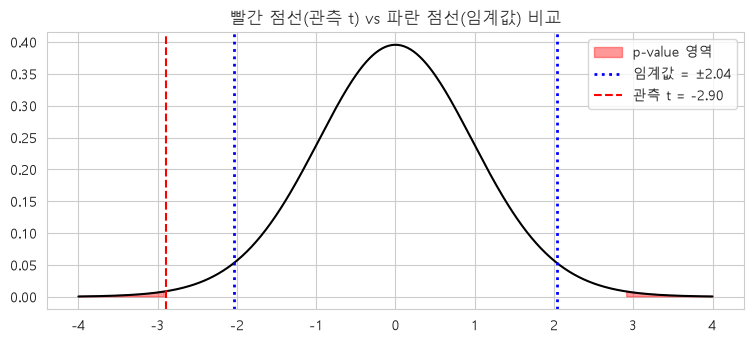

In [14]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.05
dfree =  30 # 앞서 쓰던 자유도 변수
t_critical = stats.t.ppf(1 - alpha/2, dfree)

xx = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(xx, stats.t.pdf(xx, dfree), "k", lw=1.5)

# p-value 영역 (관측된 t 기준)
ax.fill_between(xx, stats.t.pdf(xx, dfree), where=(np.abs(xx) >= abs(t_obs)),
                color="red", alpha=0.4, label="p-value 영역")

# 임계값 위치 표시 (파란 점선)
ax.axvline(t_critical, color="blue", ls=":", lw=2, label=f"임계값 = ±{t_critical:.2f}")
ax.axvline(-t_critical, color="blue", ls=":", lw=2)

# 관측 t값
ax.axvline(t_obs, color="red", ls="--", label=f"관측 t = {t_obs:.2f}")

ax.set_title("빨간 점선(관측 t) vs 파란 점선(임계값) 비교")
ax.legend()
plt.show()

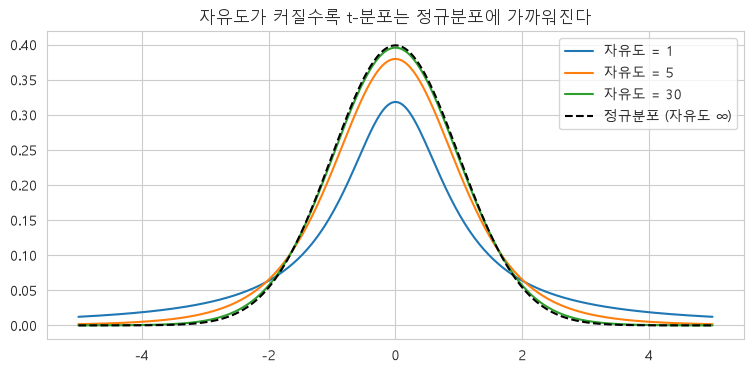

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

xx = np.linspace(-5, 5, 400)
fig, ax = plt.subplots(figsize=(9, 4))

for df in [1, 5, 30]:
    ax.plot(xx, stats.t.pdf(xx, df), label=f"자유도 = {df}")

ax.plot(xx, stats.norm.pdf(xx), 'k--', label="정규분포 (자유도 ∞)")
ax.set_title("자유도가 커질수록 t-분포는 정규분포에 가까워진다")
ax.legend()
plt.show()

In [16]:
alpha = 0.05

for df in [5, 30, 100]:
    t_crit = stats.t.ppf(1 - alpha/2, df)
    print(f"자유도 {df:3d} → 임계값 = ±{t_crit:.3f}")

자유도   5 → 임계값 = ±2.571
자유도  30 → 임계값 = ±2.042
자유도 100 → 임계값 = ±1.984


In [17]:
import numpy as np

np.random.seed(0)
true_sigma = 10

# 표본이 작을 때: s의 추정값이 표본마다 크게 요동침
s_small = [np.std(np.random.normal(0, true_sigma, size=5), ddof=1) for _ in range(1000)]
print(f"n=5일 때  s의 표준편차(변동성) = {np.std(s_small):.3f}")

# 표본이 클 때: s가 진짜 σ=10에 훨씬 안정적으로 수렴
s_large = [np.std(np.random.normal(0, true_sigma, size=200), ddof=1) for _ in range(1000)]
print(f"n=200일 때 s의 표준편차(변동성) = {np.std(s_large):.3f}")

n=5일 때  s의 표준편차(변동성) = 3.290
n=200일 때 s의 표준편차(변동성) = 0.497


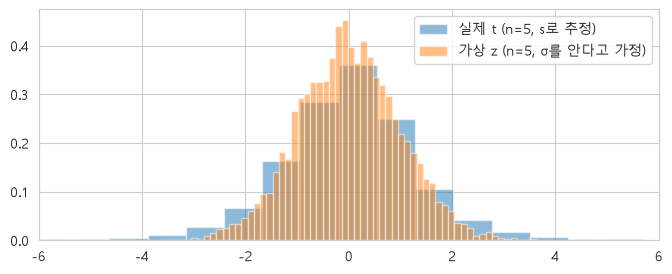

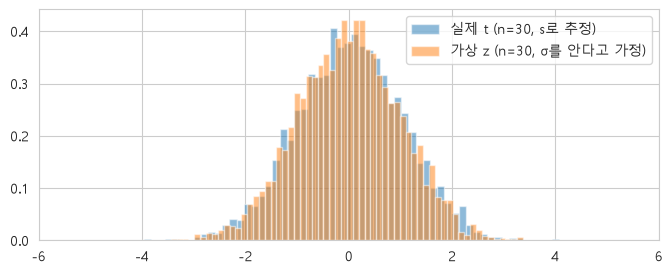

In [18]:
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(1)
n_sim = 5000

def simulate_t(n, use_true_sigma=False):
    results = []
    for _ in range(n_sim):
        sample = np.random.normal(0, true_sigma, size=n)
        if use_true_sigma:
            denom = true_sigma / np.sqrt(n)   # σ를 안다고 가정 (치팅)
        else:
            denom = np.std(sample, ddof=1) / np.sqrt(n)  # 실제로는 s로 추정
        results.append(np.mean(sample) / denom)
    return results

for n in [5, 30]:
    t_vals = simulate_t(n, use_true_sigma=False)      # 실제 t-분포 (분모도 추정)
    z_vals = simulate_t(n, use_true_sigma=True)        # 가상의 z (분모를 안다고 치팅)
    
    fig, ax = plt.subplots(figsize=(8,3))
    ax.hist(t_vals, bins=60, density=True, alpha=0.5, label=f"실제 t (n={n}, s로 추정)")
    ax.hist(z_vals, bins=60, density=True, alpha=0.5, label=f"가상 z (n={n}, σ를 안다고 가정)")
    ax.set_xlim(-6, 6)
    ax.legend()
    plt.show()

In [19]:
# [C8] 1종·2종 오류 시뮬레이션 — '정답'을 알아야 보이므로 통제 합성(seed 고정)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
N_SIM, n = 2000, 100

# (A) 진짜 차이가 '없을' 때 → 유의 판정 비율 ≈ α (1종 오류율)
false_pos = np.mean([stats.ttest_ind(np.random.normal(50, 10, n),  # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
                                      np.random.normal(50, 10, n)).pvalue < 0.05
                     for _ in range(N_SIM)])
# (B) 진짜 차이가 '있을' 때(평균차 5) → 유의 판정 비율 = 검정력
power = np.mean([stats.ttest_ind(np.random.normal(55, 10, n),     # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
                                 np.random.normal(50, 10, n)).pvalue < 0.05
                for _ in range(N_SIM)])

print(f"진짜 차이 없음 → 유의 판정 {false_pos:5.1%}   (≈ α=5%, 1종 오류)")
print(f"진짜 차이 있음 → 유의 판정 {power:5.1%}   (= 검정력 ; 나머지 {1-power:.0%}는 2종 오류)")

진짜 차이 없음 → 유의 판정  5.9%   (≈ α=5%, 1종 오류)
진짜 차이 있음 → 유의 판정 94.3%   (= 검정력 ; 나머지 6%는 2종 오류)


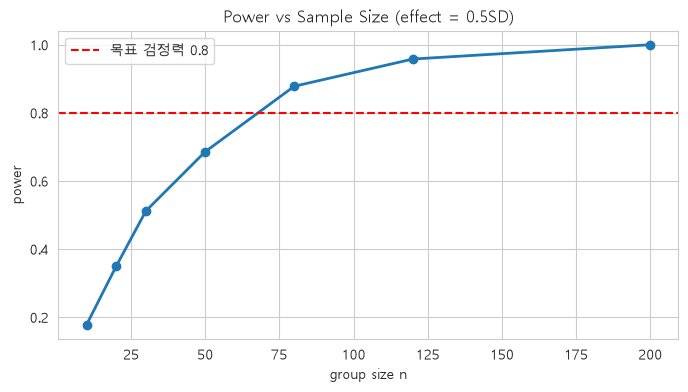

같은 효과라도 표본이 커지면 검정력이 빠르게 1.0에 다가갑니다.


In [20]:
# [C9] [그림] 검정력 곡선 — 표본이 커질수록 진짜 차이를 잘 잡는다
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
ns = [10, 20, 30, 50, 80, 120, 200]
powers = [np.mean([stats.ttest_ind(np.random.normal(55, 10, n),   # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
                                   np.random.normal(50, 10, n)).pvalue < 0.05
                   for _ in range(500)]) for n in ns]
fig, ax = plt.subplots(figsize=(8, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.plot(ns, powers, "o-", lw=2)
ax.axhline(0.8, color="red", ls="--", label="목표 검정력 0.8")         # 가로 기준선 표시
ax.set_xlabel("group size n"); ax.set_ylabel("power")
ax.set_title("Power vs Sample Size (effect = 0.5SD)"); ax.legend(); plt.show()
print("같은 효과라도 표본이 커지면 검정력이 빠르게 1.0에 다가갑니다.")

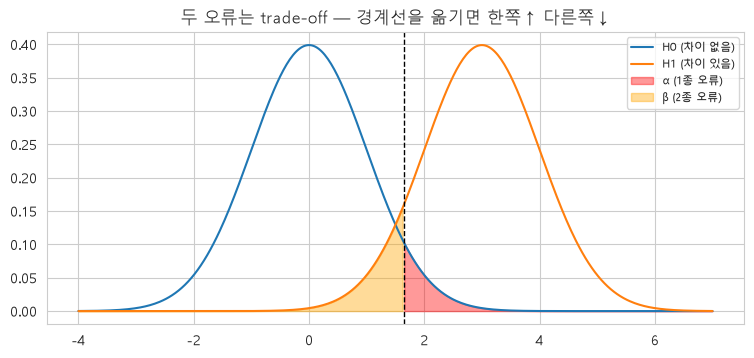

In [21]:
# [C10] [도식] 1종(α)·2종(β) 오류 — 두 가설 분포의 겹침
xx = np.linspace(-4, 7, 400)                                      # 구간을 균등 간격으로 쪼갠 x축 값
crit = stats.norm.ppf(0.95)
fig, ax = plt.subplots(figsize=(9, 3.8))                          # 그래프 하나를 그릴 도화지 준비
ax.plot(xx, stats.norm.pdf(xx, 0, 1), label="H0 (차이 없음)")
ax.plot(xx, stats.norm.pdf(xx, 3, 1), label="H1 (차이 있음)")
ax.fill_between(xx, stats.norm.pdf(xx, 0, 1), where=(xx >= crit), color="red",    alpha=0.4, label="α (1종 오류)")  # 곡선 아래 영역을 색으로 채움(= 면적은 확률)
ax.fill_between(xx, stats.norm.pdf(xx, 3, 1), where=(xx <  crit), color="orange", alpha=0.4, label="β (2종 오류)")  # 곡선 아래 영역을 색으로 채움(= 면적은 확률)
ax.axvline(crit, color="k", ls="--", lw=1)                        # 세로 기준선 표시
ax.set_title("두 오류는 trade-off — 경계선을 옮기면 한쪽↑ 다른쪽↓")
ax.legend(fontsize=8); plt.show()

In [22]:
# [C12] t-test 세 가지를 한 번에 — 모두 실데이터로
# (1) 1표본: Gentoo 펭귄 체중이 기준 5000g과 다른가?
gentoo = penguins[penguins["species"] == "Gentoo"]["body_mass_g"]
t1, p1 = stats.ttest_1samp(gentoo, 5000)                          # 한 집단 평균을 기준값과 비교
print(f"[1표본]  Gentoo {gentoo.mean():.0f}g vs 기준 5000g → t={t1:.2f}, p={p1:.3f}")

# (2) 2표본(독립): 남 vs 여 결제 금액 (Welch)
male   = tips[tips["sex"] == "Male"]["total_bill"]
female = tips[tips["sex"] == "Female"]["total_bill"]
t2, p2 = stats.ttest_ind(male, female, equal_var=False)           # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
print(f"[2표본]  남 {male.mean():.2f} vs 여 {female.mean():.2f} → t={t2:.2f}, p={p2:.3f}")

# (3) 대응표본: '같은 기업'의 1987 → 1988 불량률 (jtrain, 실데이터)
t3, p3 = stats.ttest_rel(before, after)                           # 대응표본 t-test = '차이'에 대한 1표본 t-test
print(f"[대응]   기업 {len(before)}곳의 불량률 {before.mean():.2f}% → {after.mean():.2f}%"
      f" → t={t3:.2f}, p={p3:.4f}")
print(f"         (기업별 변화량 평균 = {(after - before).mean():+.2f}%p,"
      f" 감소한 기업 {int((after < before).sum())}곳 / 증가 {int((after > before).sum())}곳)")

[1표본]  Gentoo 5076g vs 기준 5000g → t=1.67, p=0.097
[2표본]  남 20.74 vs 여 18.06 → t=2.37, p=0.019
[대응]   기업 54곳의 불량률 4.61% → 3.79% → t=2.52, p=0.0147
         (기업별 변화량 평균 = -0.82%p, 감소한 기업 34곳 / 증가 16곳)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


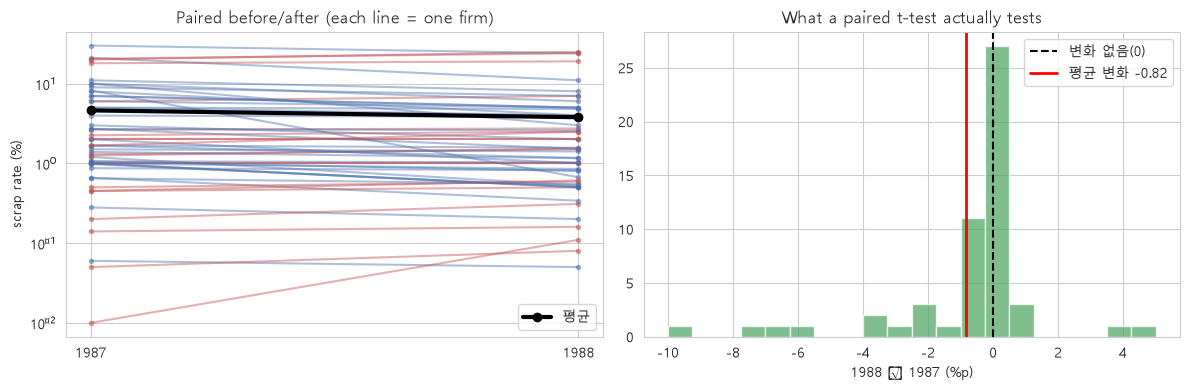

대응표본 t-test는 두 집단을 비교하는 게 아니라, '차이(오른쪽 분포)의 평균이 0인가'를 검정합니다.


In [23]:
# [C13] [그림] 대응표본 — 같은 기업의 전/후를 선으로 잇기
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                   # 그림 한 장에 그래프 2개(1행 2열)

# (왼쪽) 기업별 전→후 연결선
for b, a in zip(before, after):
    color = "#4C72B0" if a < b else "#C44E52"      # 파랑=감소, 빨강=증가
    axes[0].plot([0, 1], [b, a], color=color, alpha=0.45, marker="o", ms=3)
axes[0].plot([0, 1], [before.mean(), after.mean()], color="black", lw=3, marker="o", label="평균")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["1987", "1988"])
axes[0].set_ylabel("scrap rate (%)"); axes[0].set_yscale("log")
axes[0].set_title("Paired before/after (each line = one firm)"); axes[0].legend()

# (오른쪽) 대응표본 t-test가 실제로 보는 것 = '차이'의 분포
diff = after - before
axes[1].hist(diff, bins=20, color="#55A868", alpha=0.75)
axes[1].axvline(0, color="black", ls="--", label="변화 없음(0)")      # 세로 기준선 표시
axes[1].axvline(diff.mean(), color="red", lw=2, label=f"평균 변화 {diff.mean():+.2f}")  # 세로 기준선 표시
axes[1].set_xlabel("1988 − 1987 (%p)"); axes[1].set_title("What a paired t-test actually tests")
axes[1].legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

print("대응표본 t-test는 두 집단을 비교하는 게 아니라, '차이(오른쪽 분포)의 평균이 0인가'를 검정합니다.")

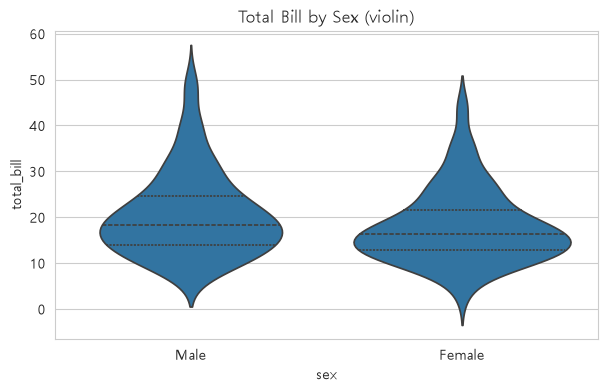

In [24]:
# [C14] [그림] 2표본 — 집단별 분포를 violin으로 한눈에
fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.violinplot(data=tips, x="sex", y="total_bill", inner="quartile", ax=ax)  # violin — 분포의 '모양'까지 보여줌
ax.set_title("Total Bill by Sex (violin)"); plt.show()

In [25]:
diff = before - after   # 기업마다 "얼마나 줄었는지"만 남김
print(diff.head())
print(f"\n차이의 평균: {diff.mean():.3f}")
print(f"차이의 표준편차: {diff.std():.3f}")

fcode
410523     0.01
410538    -0.10
410563    -1.00
410565    10.00
410566     2.00
dtype: float64

차이의 평균: 0.824
차이의 표준편차: 2.399


In [26]:
import scipy.stats as stats

# 방법 1: scipy가 바로 지원하는 함수
t_stat, p_val = stats.ttest_rel(before, after)   # rel = related(대응)
print(f"t = {t_stat:.4f}, p = {p_val:.4f}")

# 방법 2: 원리를 그대로 손으로 계산 (검증용)
diff = before - after
n = len(diff)
t_manual = diff.mean() / (diff.std(ddof=1) / np.sqrt(n))
dfree = n - 1   # 자유도는 "차이값의 개수 - 1" 하나뿐!

print(f"직접 계산한 t = {t_manual:.4f}")
print(f"자유도 = {dfree}")

t = 2.5232, p = 0.0147
직접 계산한 t = 2.5232
자유도 = 53


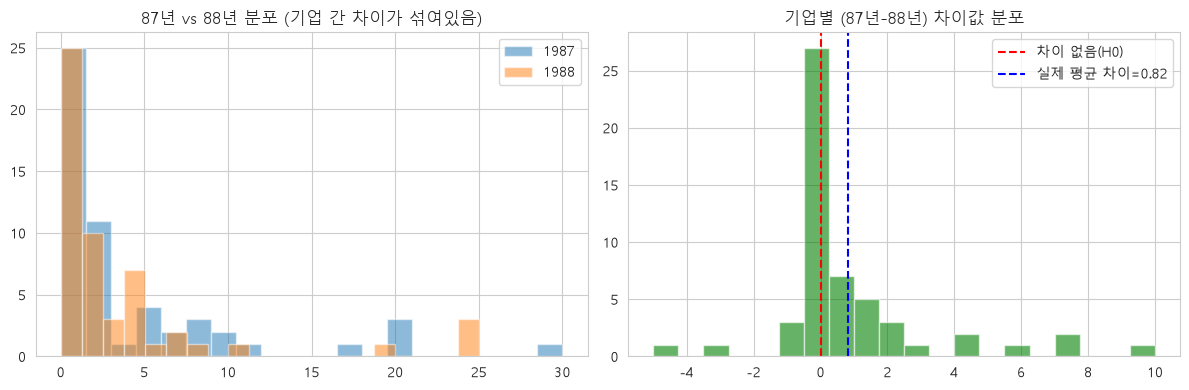

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (왼쪽) 그냥 87년 vs 88년 분포만 보면 — 겹쳐 보임
axes[0].hist(before, bins=20, alpha=0.5, label='1987')
axes[0].hist(after, bins=20, alpha=0.5, label='1988')
axes[0].set_title("87년 vs 88년 분포 (기업 간 차이가 섞여있음)")
axes[0].legend()

# (오른쪽) 각 기업의 '차이'만 뽑아보면 — 훨씬 선명함
axes[1].hist(diff, bins=20, color='green', alpha=0.6)
axes[1].axvline(0, color='red', ls='--', label='차이 없음(H0)')
axes[1].axvline(diff.mean(), color='blue', ls='--', label=f'실제 평균 차이={diff.mean():.2f}')
axes[1].set_title("기업별 (87년-88년) 차이값 분포")
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# [C15] [비교] 등분산 가정 여부에 따른 2표본 t-test
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
a = np.random.normal(50,  5, 40)    # 퍼짐 작음
b = np.random.normal(53, 15, 40)    # 퍼짐 큼 (표준편차 약 3배)

student = stats.ttest_ind(a, b, equal_var=True)                   # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
welch   = stats.ttest_ind(a, b, equal_var=False)                  # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
print(f"두 집단 표준편차 : a = {a.std(ddof=1):.1f},  b = {b.std(ddof=1):.1f}")
print(f"Student's t : t = {student.statistic:6.3f},  p = {student.pvalue:.4f}   (등분산 가정)")
print(f"Welch's   t : t = {welch.statistic:6.3f},  p = {welch.pvalue:.4f}   (등분산 가정 안 함)")
print()
print("→ 분산이 다를수록 두 방법의 결과가 벌어집니다. 의심되면 Welch가 안전합니다.")

두 집단 표준편차 : a = 4.8,  b = 14.5
Student's t : t = -1.518,  p = 0.1330   (등분산 가정)
Welch's   t : t = -1.518,  p = 0.1356   (등분산 가정 안 함)

→ 분산이 다를수록 두 방법의 결과가 벌어집니다. 의심되면 Welch가 안전합니다.


In [29]:
# ─────────────────────────────────────────────
# [C6] Adelie 펭귄 체중 vs 기준값 3700g — 1표본 t-test
# ─────────────────────────────────────────────

adelie_weight = penguins.loc[penguins['species'] == 'Adelie', 'body_mass_g']

print(f"Adelie 펭귄 n = {len(adelie_weight)}")
print(f"표본 평균 = {adelie_weight.mean():.2f}g")
print(f"표본 표준편차 = {adelie_weight.std():.2f}g")

# 1표본 t-test: 표본평균이 기준값(3700)과 다른지 검정
t_stat, p_val = stats.ttest_1samp(adelie_weight, popmean=3700)

print(f"\nt 통계량 = {t_stat:.4f}")
print(f"p-value  = {p_val:.4f}")
print(f"자유도 = {len(adelie_weight) - 1}")   # 1표본 t-test 자유도 = n - 1

Adelie 펭귄 n = 151
표본 평균 = 3700.66g
표본 표준편차 = 458.57g

t 통계량 = 0.0177
p-value  = 0.9859
자유도 = 150


In [30]:
# ─────────────────────────────────────────────
# [C7] 판정 — p-value 기반 결론
# ─────────────────────────────────────────────

alpha = 0.05

print("① H0 : Adelie 펭귄의 평균 체중은 3700g이다.")
print("   H1 : Adelie 펭귄의 평균 체중은 3700g이 아니다.")
print(f"② 유의수준 α = {alpha}")
print(f"③ 검정통계량 t = {t_stat:.4f}")
print(f"④ p-value = {p_val:.4f}")

print(f"\n[5] 판단")
if p_val < alpha:
    print(f"p-value({p_val:.4f}) < α({alpha}) → H0를 기각한다")
else:
    print(f"p-value({p_val:.4f}) ≥ α({alpha}) → H0를 기각하지 못한다")

print(f"\n[6] 결론")
diff_from_ref = adelie_weight.mean() - 3700
if p_val < alpha:
    print(f"Adelie 펭귄의 평균 체중({adelie_weight.mean():.1f}g)은 기준값 3700g과 "
          f"통계적으로 유의미하게 다르다.")
    print(f"(표본 평균이 기준보다 {'높음' if diff_from_ref > 0 else '낮음'}, 차이 = {diff_from_ref:+.1f}g)")
else:
    print(f"Adelie 펭귄의 평균 체중({adelie_weight.mean():.1f}g)이 기준값 3700g과 "
          f"다르다고 보기에는 근거가 충분하지 않다.")
    print(f"(관측된 차이 {diff_from_ref:+.1f}g는 우연(샘플링 변동)만으로도 설명 가능한 수준)")

① H0 : Adelie 펭귄의 평균 체중은 3700g이다.
   H1 : Adelie 펭귄의 평균 체중은 3700g이 아니다.
② 유의수준 α = 0.05
③ 검정통계량 t = 0.0177
④ p-value = 0.9859

[5] 판단
p-value(0.9859) ≥ α(0.05) → H0를 기각하지 못한다

[6] 결론
Adelie 펭귄의 평균 체중(3700.7g)이 기준값 3700g과 다르다고 보기에는 근거가 충분하지 않다.
(관측된 차이 +0.7g는 우연(샘플링 변동)만으로도 설명 가능한 수준)


In [31]:
# ─────────────────────────────────────────────
# [C8] '차이값'에 1표본 t-test(기준 0) → 대응표본 t-test와 t·p 일치 확인
# ─────────────────────────────────────────────

diff_after_before = after - before   # after - before로 방향 통일

# 방법 A: 대응표본 t-test (paired)
t_paired, p_paired = stats.ttest_rel(after, before)   # after - before 방향

# 방법 B: 차이값에 대한 1표본 t-test (기준값 0)
t_1samp, p_1samp = stats.ttest_1samp(diff_after_before, popmean=0)

print("[방법 A] 대응표본 t-test (ttest_rel)")
print(f"  t = {t_paired:.6f}, p = {p_paired:.6f}")

print("\n[방법 B] 차이값에 대한 1표본 t-test (기준 0)")
print(f"  t = {t_1samp:.6f}, p = {p_1samp:.6f}")

print(f"\n두 t값 일치 여부: {np.isclose(t_paired, t_1samp)}")
print(f"두 p값 일치 여부: {np.isclose(p_paired, p_1samp)}")

[방법 A] 대응표본 t-test (ttest_rel)
  t = -2.523240, p = 0.014663

[방법 B] 차이값에 대한 1표본 t-test (기준 0)
  t = -2.523240, p = 0.014663

두 t값 일치 여부: True
두 p값 일치 여부: True


In [32]:
# ─────────────────────────────────────────────
# [C9] 2표본 vs 대응표본 — 왜 대응표본이 더 민감한가
# ─────────────────────────────────────────────

print("[핵심 차이]")
print("- 2표본(독립) t-test : 두 그룹의 '평균'만 비교. 개체 간 원래 차이(개인차)는 그대로 잡음(noise)으로 남음")
print("- 대응표본 t-test    : 같은 개체의 '차이(before-after)'만 봄. 개체 간 원래 차이가 상쇄되어 사라짐")
print()

# 개체 간 원래 차이가 큰 상황을 시뮬레이션
np.random.seed(42)
n = 30

baseline = np.random.normal(50, 15, size=n)     # 기업마다 원래 실력이 천차만별 (분산 큼)
true_effect = 3                                  # 실제 정책 효과는 3만큼 감소
noise = np.random.normal(0, 2, size=n)           # 측정 시점의 순수 잡음은 작음

before_sim = baseline
after_sim  = baseline - true_effect + noise      # 같은 대상이 정책 효과 + 약간의 잡음만큼 변화

# (A) 독립표본처럼 취급 (개체 연결 정보 무시)
t_ind, p_ind = stats.ttest_ind(before_sim, after_sim)

# (B) 대응표본으로 취급 (개체 연결 정보 활용)
t_pair, p_pair = stats.ttest_rel(before_sim, after_sim)

print(f"[독립표본으로 취급] t = {t_ind:.4f}, p = {p_ind:.4f}")
print(f"[대응표본으로 취급] t = {t_pair:.4f}, p = {p_pair:.4f}")

print(f"\n개체 간 원래 값(baseline)의 분산: {baseline.var():.2f}  ← 이게 독립표본에서는 잡음으로 남음")
print(f"진짜 효과 + 측정잡음(after_sim - before_sim)의 분산: {(after_sim - before_sim).var():.2f}  ← 대응표본은 이것만 봄")

[핵심 차이]
- 2표본(독립) t-test : 두 그룹의 '평균'만 비교. 개체 간 원래 차이(개인차)는 그대로 잡음(noise)으로 남음
- 대응표본 t-test    : 같은 개체의 '차이(before-after)'만 봄. 개체 간 원래 차이가 상쇄되어 사라짐

[독립표본으로 취급] t = 0.9196, p = 0.3616
[대응표본으로 취급] t = 9.5365, p = 0.0000

개체 간 원래 값(baseline)의 분산: 176.18  ← 이게 독립표본에서는 잡음으로 남음
진짜 효과 + 측정잡음(after_sim - before_sim)의 분산: 3.35  ← 대응표본은 이것만 봄


ANOVA: F=343.6, p=2.89e-82, η²=0.67  (체중 변동의 67%를 '종'이 설명)
등분산(Levene) p=0.006 → 등분산 위배! Welch ANOVA/비모수 고려


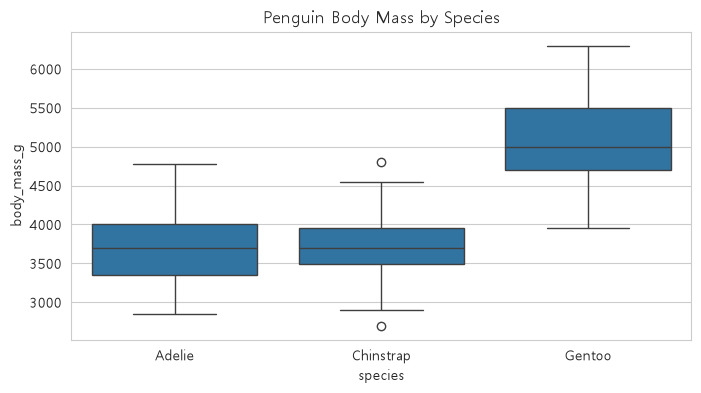


[Tukey HSD — 어느 쌍이 다른가]
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


In [33]:
# [C17] 일원 ANOVA: 세 종의 체중이 다른가?
groups = [g["body_mass_g"].values for _, g in penguins.groupby("species")]  # 집단별로 묶어서 계산
F, p = stats.f_oneway(*groups)                                    # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산

grand = penguins["body_mass_g"].mean()
ss_b = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
ss_t = ((penguins["body_mass_g"] - grand) ** 2).sum()
eta2 = ss_b / ss_t
lev = stats.levene(*groups).pvalue                                # 등분산 검정 — p가 작으면 등분산 가정 위배

print(f"ANOVA: F={F:.1f}, p={p:.2e}, η²={eta2:.2f}  (체중 변동의 {eta2:.0%}를 '종'이 설명)")
print(f"등분산(Levene) p={lev:.3f} → {'등분산 위배! Welch ANOVA/비모수 고려' if lev<0.05 else '등분산 OK'}")

fig, ax = plt.subplots(figsize=(8, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax)   # 상자그림 — 중앙값·사분위·이상치를 한눈에
ax.set_title("Penguin Body Mass by Species"); plt.show()

print("\n[Tukey HSD — 어느 쌍이 다른가]")
print(pairwise_tukeyhsd(penguins["body_mass_g"], penguins["species"]))  # 사후검정: 어느 '쌍'이 다른지 (다중비교 보정 포함)

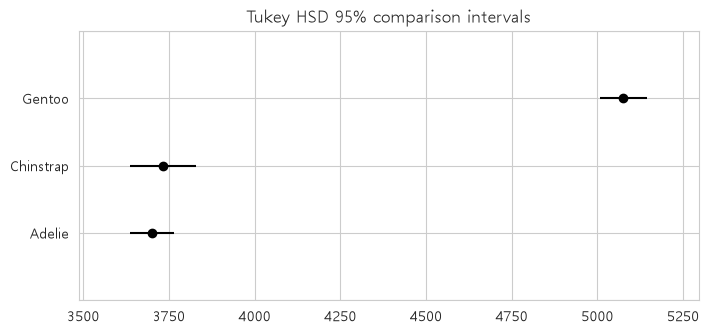

In [34]:
# [C19] [그림] Tukey HSD — 신뢰구간이 겹치지 않으면 유의 차이
tuk = pairwise_tukeyhsd(penguins["body_mass_g"], penguins["species"])  # 사후검정: 어느 '쌍'이 다른지 (다중비교 보정 포함)
tuk.plot_simultaneous(figsize=(8, 3.5))
plt.title("Tukey HSD 95% comparison intervals"); plt.show()


In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('body_mass_g ~ species', data=penguins).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

ss_between_sm = anova_table['sum_sq']['species']
ss_total_sm = anova_table['sum_sq'].sum()
eta_sq_sm = ss_between_sm / ss_total_sm

print(f"\nη² (statsmodels 결과로 계산) = {eta_sq_sm:.4f}")

                sum_sq     df           F        PR(>F)
species   1.468642e+08    2.0  343.626275  2.892368e-82
Residual  7.244348e+07  339.0         NaN           NaN

η² (statsmodels 결과로 계산) = 0.6697


In [36]:
# 실제로 회귀분석의 R²와 일치하는지 확인
r_squared = model.rsquared
print(f"회귀분석(ols) R² = {r_squared:.4f}")
print(f"ANOVA η²        = {eta_squared:.4f}")
print(f"일치 여부: {np.isclose(r_squared, eta_squared)}")

회귀분석(ols) R² = 0.6697


NameError: name 'eta_squared' is not defined

In [ ]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# penguins로 예시: 부리길이(bill_length_mm)로 체중(body_mass_g) 예측
data = penguins.dropna(subset=['bill_length_mm', 'body_mass_g'])

model = ols('body_mass_g ~ bill_length_mm', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     186.4
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.81e-34
Time:                        22:03:04   Log-Likelihood:                -2697.0
No. Observations:                 342   AIC:                             5398.
Df Residuals:                     340   BIC:                             5406.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        362.3067    283.345      1.

In [ ]:
y = data['body_mass_g']
y_pred = model.predict(data)
y_mean = y.mean()

ss_total = ((y - y_mean) ** 2).sum()          # 베이스라인(평균으로만 예측)의 오차
ss_residual = ((y - y_pred) ** 2).sum()        # 모델 예측의 오차
ss_explained = ss_total - ss_residual

r_squared_manual = 1 - (ss_residual / ss_total)

print(f"SS_total    (베이스라인 오차) = {ss_total:,.0f}")
print(f"SS_residual (모델 오차)      = {ss_residual:,.0f}")
print(f"SS_explained(줄어든 오차)    = {ss_explained:,.0f}")
print(f"\nR² (직접 계산) = {r_squared_manual:.4f}")
print(f"R² (statsmodels) = {model.rsquared:.4f}")

SS_total    (베이스라인 오차) = 219,307,697
SS_residual (모델 오차)      = 141,638,626
SS_explained(줄어든 오차)    = 77,669,072

R² (직접 계산) = 0.3542
R² (statsmodels) = 0.3542


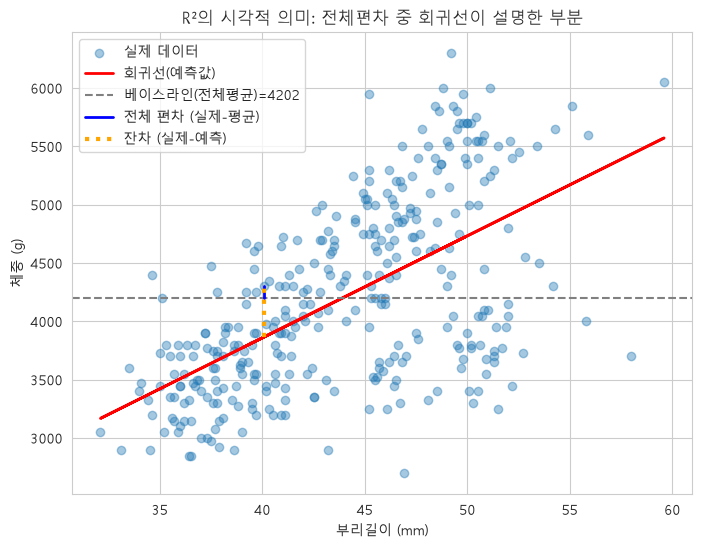

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data['bill_length_mm'], y, alpha=0.4, label='실제 데이터')
ax.plot(data['bill_length_mm'], y_pred, color='red', lw=2, label='회귀선(예측값)')
ax.axhline(y_mean, color='gray', ls='--', label=f'베이스라인(전체평균)={y_mean:.0f}')

# 임의 한 점 골라서 세 가지 편차를 시각적으로 표시
idx = 50
x_point = data['bill_length_mm'].iloc[idx]
y_actual = y.iloc[idx]
y_hat = y_pred.iloc[idx]

ax.plot([x_point, x_point], [y_mean, y_actual], color='blue', lw=2, label='전체 편차 (실제-평균)')
ax.plot([x_point, x_point], [y_hat, y_actual], color='orange', lw=3, ls=':', label='잔차 (실제-예측)')

ax.set_xlabel('부리길이 (mm)')
ax.set_ylabel('체중 (g)')
ax.set_title('R²의 시각적 의미: 전체편차 중 회귀선이 설명한 부분')
ax.legend()
plt.show()

In [37]:
# [C22] 효과 크기 3종 세트 — tips 성별 차이를 '제대로' 보고하기
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

t, p = stats.ttest_ind(male, female, equal_var=False)             # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
diff = male.mean() - female.mean()
se = np.sqrt(male.var(ddof=1)/len(male) + female.var(ddof=1)/len(female))
df = se**4 / ((male.var(ddof=1)/len(male))**2/(len(male)-1) + (female.var(ddof=1)/len(female))**2/(len(female)-1))
lo, hi = diff - stats.t.ppf(0.975, df)*se, diff + stats.t.ppf(0.975, df)*se
d = cohens_d(male, female)
size = "작음" if abs(d) < 0.5 else ("중간" if abs(d) < 0.8 else "큼")

print("[남녀 결제 금액 차이 — 3종 세트 보고]")
print(f"  ① 점추정(평균차) : {diff:.2f} 달러")
print(f"  ② 95% 신뢰구간   : [{lo:.2f}, {hi:.2f}]")
print(f"  ③ 효과 크기(d)   : {d:.2f}  → {size} 효과")
print(f"  (참고: p = {p:.3f})")

[남녀 결제 금액 차이 — 3종 세트 보고]
  ① 점추정(평균차) : 2.69 달러
  ② 95% 신뢰구간   : [0.45, 4.92]
  ③ 효과 크기(d)   : 0.30  → 작음 효과
  (참고: p = 0.019)


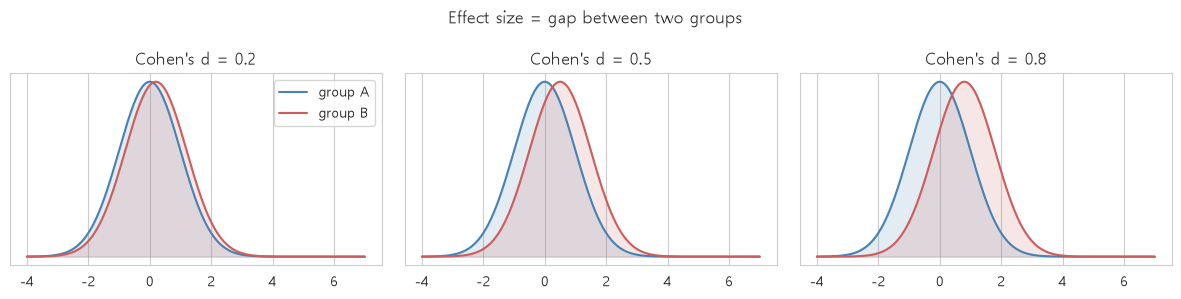

In [38]:
# [C24] [도식] Cohen's d 감 잡기 — d가 클수록 두 집단 분포가 멀어진다
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)      # 그림 한 장에 그래프 3개(1행 3열)
x = np.linspace(-4, 7, 400)                                       # 구간을 균등 간격으로 쪼갠 x축 값
for ax, d in zip(axes, [0.2, 0.5, 0.8]):
    ax.plot(x, stats.norm.pdf(x, 0, 1), color="steelblue")
    ax.plot(x, stats.norm.pdf(x, d, 1), color="indianred")
    ax.fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.15, color="steelblue")  # 곡선 아래 영역을 색으로 채움(= 면적은 확률)
    ax.fill_between(x, stats.norm.pdf(x, d, 1), alpha=0.15, color="indianred")  # 곡선 아래 영역을 색으로 채움(= 면적은 확률)
    ax.set_title(f"Cohen's d = {d}"); ax.set_yticks([])
axes[0].legend(["group A", "group B"])
plt.suptitle("Effect size = gap between two groups"); plt.tight_layout(); plt.show()  # 그래프 간격 자동 정리 후 출력

In [39]:
# [C26] 시나리오 1·2 — 2표본 비교 자동 요약
def compare_two(df, value, group, a, b):
    x = df[df[group] == a][value].dropna()                        # 결측(NaN) 제거
    y = df[df[group] == b][value].dropna()                        # 결측(NaN) 제거
    t, p = stats.ttest_ind(x, y, equal_var=False)                 # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
    return {"비교": f"{a} vs {b}", "평균차": round(x.mean() - y.mean(), 2),
            "t": round(t, 2), "p": round(p, 4), "Cohen's d": round(cohens_d(x, y), 2),
            "판정": "유의" if p < 0.05 else "유의 아님"}

report = pd.DataFrame([
    compare_two(tips, "total_bill", "sex",  "Male",   "Female"),
    compare_two(tips, "total_bill", "time", "Dinner", "Lunch"),
])
report

,비교,평균차,t,p,Cohen's d,판정
0,Male vs Female,2.69,2.37,0.0186,0.30,유의
1,Dinner vs Lunch,3.63,3.12,0.0022,0.41,유의


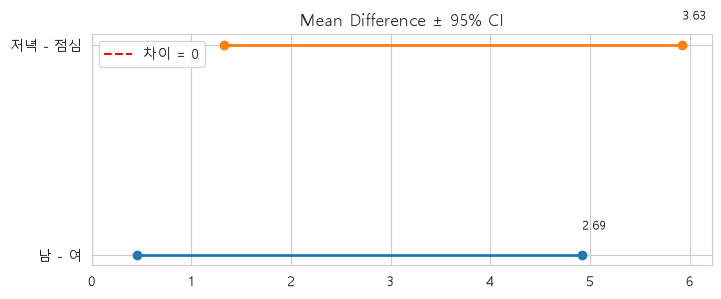

In [40]:
# [C27] [그림] 두 비교의 평균차 ± 95% CI (forest plot) — 0을 넘으면 유의
def diff_ci(x, y):
    d = x.mean() - y.mean()
    se = np.sqrt(x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))
    df = se**4 / ((x.var(ddof=1)/len(x))**2/(len(x)-1) + (y.var(ddof=1)/len(y))**2/(len(y)-1))
    h = stats.t.ppf(0.975, df) * se
    return d, d - h, d + h

rows = [("남 - 여", *diff_ci(male, female)),
        ("저녁 - 점심", *diff_ci(tips[tips.time == "Dinner"].total_bill, tips[tips.time == "Lunch"].total_bill))]
fig, ax = plt.subplots(figsize=(8, 3))                            # 그래프 하나를 그릴 도화지 준비
for i, (lab, d, lo, hi) in enumerate(rows):
    ax.plot([lo, hi], [i, i], "o-", lw=2)
    ax.text(hi, i + 0.12, f"{d:.2f}", fontsize=9)
ax.axvline(0, color="red", ls="--", label="차이 = 0")               # 세로 기준선 표시
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows]); ax.set_xlim(left=0)
ax.set_title("Mean Difference ± 95% CI"); ax.legend(); plt.show()

In [41]:
# [C28] 시나리오 3 — ANOVA 요약
groups = [g["body_mass_g"].values for _, g in penguins.groupby("species")]  # 집단별로 묶어서 계산
F, p = stats.f_oneway(*groups)                                    # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산
grand = penguins["body_mass_g"].mean()
eta2 = sum(len(g)*(g.mean()-grand)**2 for g in groups) / ((penguins["body_mass_g"]-grand)**2).sum()
print(f"종별 체중 ANOVA: F={F:.1f}, p={p:.2e}, η²={eta2:.2f}")
print("Tukey 요약: Adelie≈Chinstrap, 둘 다 Gentoo와 유의하게 다름 (Gentoo가 무겁다)")

종별 체중 ANOVA: F=343.6, p=2.89e-82, η²=0.67
Tukey 요약: Adelie≈Chinstrap, 둘 다 Gentoo와 유의하게 다름 (Gentoo가 무겁다)


In [42]:
# [C28b] 시나리오 4 — 대응표본 3종 세트
diff = after - before
n = len(diff)
se_d = diff.std(ddof=1) / np.sqrt(n)
lo_d, hi_d = diff.mean() - stats.t.ppf(0.975, n - 1) * se_d, diff.mean() + stats.t.ppf(0.975, n - 1) * se_d
d_paired = diff.mean() / diff.std(ddof=1)          # 대응표본용 Cohen's d (차이 / 차이의 표준편차)
t3, p3 = stats.ttest_rel(after, before)                           # 대응표본 t-test = '차이'에 대한 1표본 t-test

print("[불량률 1987 → 1988 (같은 기업 %d곳)]" % n)
print(f"  ① 점추정(평균 변화) : {diff.mean():+.2f} %p")
print(f"  ② 95% 신뢰구간      : [{lo_d:+.2f}, {hi_d:+.2f}] %p")
print(f"  ③ 효과 크기(d)      : {d_paired:.2f}")
print(f"  (참고: t({n-1}) = {t3:.2f}, p = {p3:.4f})")

# 정규성이 의심되면? 차이의 분포를 확인하고, 비모수 대안도 함께 (다음 시간 예고)
print(f"\n  차이의 정규성(Shapiro) p = {stats.shapiro(diff).pvalue:.2e}  → 정규 가정이 약함")  # 정규성 검정 — H0: 정규분포를 따른다
print(f"  비모수 대안 Wilcoxon 부호순위 p = {stats.wilcoxon(before, after).pvalue:.4f}  (D014에서 배웁니다)")  # Wilcoxon 부호순위 — 대응표본 t-test의 비모수 짝꿍

[불량률 1987 → 1988 (같은 기업 54곳)]
  ① 점추정(평균 변화) : -0.82 %p
  ② 95% 신뢰구간      : [-1.48, -0.17] %p
  ③ 효과 크기(d)      : -0.34
  (참고: t(53) = -2.52, p = 0.0147)

  차이의 정규성(Shapiro) p = 2.20e-08  → 정규 가정이 약함
  비모수 대안 Wilcoxon 부호순위 p = 0.0029  (D014에서 배웁니다)


In [43]:
# [C28c] 시나리오 5 — Project STAR: 학급 유형 3집단 ANOVA + Tukey
groups_star = [g["tmathssk"].values for _, g in star.groupby("classk")]  # 집단별로 묶어서 계산
F_s, p_s = stats.f_oneway(*groups_star)                           # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산
grand_s = star["tmathssk"].mean()
eta2_s = (sum(len(g) * (g.mean() - grand_s) ** 2 for g in groups_star)
          / ((star["tmathssk"] - grand_s) ** 2).sum())

print("[Project STAR — 유치원 수학 점수]")
print(star.groupby("classk")["tmathssk"].agg(["count", "mean", "std"]).round(2))  # 집단별로 묶어서 계산
print(f"\nANOVA: F({len(groups_star)-1}, {len(star)-len(groups_star)}) = {F_s:.2f}, "
      f"p = {p_s:.2e}, η² = {eta2_s:.4f}")
print(f"등분산(Levene) p = {stats.levene(*groups_star).pvalue:.3f}")  # 등분산 검정 — p가 작으면 등분산 가정 위배

print("\n[Tukey HSD — 어느 쌍이 다른가]")
print(pairwise_tukeyhsd(star["tmathssk"], star["classk"]))        # 사후검정: 어느 '쌍'이 다른지 (다중비교 보정 포함)

[Project STAR — 유치원 수학 점수]
                   count    mean    std
classk                                 
regular             2000  483.26  47.50
regular.with.aide   2015  483.01  46.11
small.class         1733  491.47  49.47

ANOVA: F(2, 5745) = 18.55, p = 9.30e-09, η² = 0.0064
등분산(Levene) p = 0.001

[Tukey HSD — 어느 쌍이 다른가]
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
          regular regular.with.aide  -0.2511 0.9847 -3.7752  3.2731  False
          regular       small.class   8.2093    0.0  4.5451 11.8735   True
regular.with.aide       small.class   8.4604    0.0  4.8025 12.1182   True
--------------------------------------------------------------------------


In [44]:
# [C30] [도구] 상황을 넣으면 적절한 검정을 추천하는 미니 가이드
def recommend_test(n_groups, paired=False, normal=True, equal_var=True):
    """집단 수·짝지음·정규성·등분산 → 권장 검정 이름"""
    if n_groups == 1:
        return "1표본 t-test" if normal else "Wilcoxon 부호순위 검정 (비모수)"
    if n_groups == 2:
        if paired:
            return "대응표본 t-test" if normal else "Wilcoxon 부호순위 검정 (비모수)"
        if not normal:
            return "Mann-Whitney U 검정 (비모수)"
        return "Student's t-test" if equal_var else "Welch's t-test"
    # 3집단 이상
    if not normal:
        return "Kruskal-Wallis 검정 (비모수) → 사후 Dunn"
    return "일원 ANOVA → 사후 Tukey HSD"

cases = [
    dict(n_groups=1, normal=True),
    dict(n_groups=2, paired=True,  normal=True),
    dict(n_groups=2, paired=False, normal=True, equal_var=False),
    dict(n_groups=2, paired=False, normal=False),
    dict(n_groups=3, paired=False, normal=True),
    dict(n_groups=3, paired=False, normal=False),
]
for c in cases:
    print(f"{str(c):<62} → {recommend_test(**c)}")

{'n_groups': 1, 'normal': True}                                → 1표본 t-test
{'n_groups': 2, 'paired': True, 'normal': True}                → 대응표본 t-test
{'n_groups': 2, 'paired': False, 'normal': True, 'equal_var': False} → Welch's t-test
{'n_groups': 2, 'paired': False, 'normal': False}              → Mann-Whitney U 검정 (비모수)
{'n_groups': 3, 'paired': False, 'normal': True}               → 일원 ANOVA → 사후 Tukey HSD
{'n_groups': 3, 'paired': False, 'normal': False}              → Kruskal-Wallis 검정 (비모수) → 사후 Dunn
